# Variance Analysis

## Financial Services Performance Analytics Platform

### Objective

Analyze actual monthly transaction performance against a historical 3-month baseline to identify significant positive and negative variances.

**Analysis Period:** January 2024 – December 2025

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
transactions = pd.read_csv("../data/raw/transactions.csv")

transactions.head()

,transaction_id,customer_id,account_id,transaction_date,transaction_type,amount,merchant_category,channel,status
0,1,3433,971,2024-08-04,Payment,46.54,Transportation,Online,Completed
1,2,1279,3842,2025-06-23,Payment,83.94,Healthcare,Branch,Completed
2,3,103,6447,2024-02-27,Deposit,15.70,Retail,Phone,Pending
3,4,1882,4429,2025-02-03,Transfer,17.43,Grocery,Mobile,Failed
4,5,4031,3594,2025-09-15,Deposit,87.22,Travel,Branch,Failed


In [3]:
transactions.info()

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions["status"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   transaction_id     100000 non-null  int64  
 1   customer_id        100000 non-null  int64  
 2   account_id         100000 non-null  int64  
 3   transaction_date   100000 non-null  str    
 4   transaction_type   100000 non-null  str    
 5   amount             100000 non-null  float64
 6   merchant_category  100000 non-null  str    
 7   channel            100000 non-null  str    
 8   status             100000 non-null  str    
dtypes: float64(1), int64(3), str(5)
memory usage: 6.9 MB


status
Completed    66683
Pending      16662
Failed       16655
Name: count, dtype: int64

In [4]:
completed = transactions[transactions["status"] == "Completed"].copy()

completed.shape

completed.head()

,transaction_id,customer_id,account_id,transaction_date,transaction_type,amount,merchant_category,channel,status
0,1,3433,971,2024-08-04,Payment,46.54,Transportation,Online,Completed
1,2,1279,3842,2025-06-23,Payment,83.94,Healthcare,Branch,Completed
6,7,3590,3136,2025-08-26,Purchase,97.68,Education,Phone,Completed
7,8,2079,675,2025-01-09,Withdrawal,67.47,Transportation,Mobile,Completed
8,9,2541,823,2024-03-29,Purchase,78.08,Transportation,Mobile,Completed


In [5]:
# Monthly Actuals
monthly_actuals = (
    completed
    .assign(
        month=completed["transaction_date"].dt.to_period("M").dt.to_timestamp()
    )
    .groupby("month")
    .agg(
        actual_transactions=("transaction_id", "count"),
        actual_transaction_value=("amount", "sum"),
        actual_active_customers=("customer_id", "nunique")
    )
    .reset_index()
)

monthly_actuals

,month,actual_transactions,actual_transaction_value,actual_active_customers
0,2024-01-01,2818,1130535.53,1909
1,2024-02-01,2690,1176052.91,1813
2,2024-03-01,2887,1141349.90,1934
3,2024-04-01,2761,991423.66,1811
4,2024-05-01,2780,893482.18,1869
5,2024-06-01,2736,1410588.64,1833
6,2024-07-01,2824,963982.30,1878
7,2024-08-01,2806,889335.30,1866
8,2024-09-01,2741,895349.70,1853
9,2024-10-01,2845,1215672.46,1896


In [6]:
# Calculate Expected Baseline
monthly_actuals["expected_transaction_value"] = (
    monthly_actuals["actual_transaction_value"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

monthly_actuals["expected_transactions"] = (
    monthly_actuals["actual_transactions"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

monthly_actuals["expected_active_customers"] = (
    monthly_actuals["actual_active_customers"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

In [7]:
# Calculate Transaction Value Variance 

monthly_actuals["transaction_value_variance"] = (
    monthly_actuals["actual_transaction_value"]
    - monthly_actuals["expected_transaction_value"]
)

In [8]:
monthly_actuals["transaction_value_variance_percent"] = (
    monthly_actuals["transaction_value_variance"]
    / monthly_actuals["expected_transaction_value"]
) * 100

In [9]:
#  Calculate Transaction Count Variance

monthly_actuals["transaction_count_variance"] = (
    monthly_actuals["actual_transactions"]
    - monthly_actuals["expected_transactions"]
)

monthly_actuals["transaction_count_variance_percent"] = (
    monthly_actuals["transaction_count_variance"]
    / monthly_actuals["expected_transactions"]
) * 100

In [10]:
# Calculate Customer Variance

monthly_actuals["customer_variance"] = (
    monthly_actuals["actual_active_customers"]
    - monthly_actuals["expected_active_customers"]
)

monthly_actuals["customer_variance_percent"] = (
    monthly_actuals["customer_variance"]
    / monthly_actuals["expected_active_customers"]
) * 100


In [11]:
# Performance Classification
monthly_actuals["performance_status"] = "Insufficient History"

valid_baseline = (
    monthly_actuals["expected_transaction_value"].notna()
)

monthly_actuals.loc[
    valid_baseline
    & (
        monthly_actuals["actual_transaction_value"]
        > monthly_actuals["expected_transaction_value"]
    ),
    "performance_status"
] = "Above Baseline"

monthly_actuals.loc[
    valid_baseline
    & (
        monthly_actuals["actual_transaction_value"]
        < monthly_actuals["expected_transaction_value"]
    ),
    "performance_status"
] = "Below Baseline"

monthly_actuals.loc[
    valid_baseline
    & (
        monthly_actuals["actual_transaction_value"]
        == monthly_actuals["expected_transaction_value"]
    ),
    "performance_status"
] = "At Baseline"

In [12]:
# Final Variance Table
variance_analysis = monthly_actuals[
    [
        "month",
        "actual_transaction_value",
        "expected_transaction_value",
        "transaction_value_variance",
        "transaction_value_variance_percent",
        "actual_transactions",
        "expected_transactions",
        "transaction_count_variance",
        "transaction_count_variance_percent",
        "actual_active_customers",
        "expected_active_customers",
        "customer_variance",
        "customer_variance_percent",
        "performance_status"
    ]
].copy()

variance_analysis

,month,actual_transaction_value,expected_transaction_value,transaction_value_variance,transaction_value_variance_percent,actual_transactions,expected_transactions,transaction_count_variance,transaction_count_variance_percent,actual_active_customers,expected_active_customers,customer_variance,customer_variance_percent,performance_status
0,2024-01-01,1130535.53,NaN,NaN,NaN,2818,NaN,NaN,NaN,1909,NaN,NaN,NaN,Insufficient History
1,2024-02-01,1176052.91,NaN,NaN,NaN,2690,NaN,NaN,NaN,1813,NaN,NaN,NaN,Insufficient History
2,2024-03-01,1141349.90,NaN,NaN,NaN,2887,NaN,NaN,NaN,1934,NaN,NaN,NaN,Insufficient History
3,2024-04-01,991423.66,1.149313e+06,-157889.120000,-13.737698,2761,2798.333333,-37.333333,-1.334127,1811,1885.333333,-74.333333,-3.942716,Below Baseline
4,2024-05-01,893482.18,1.102942e+06,-209459.976667,-18.991021,2780,2779.333333,0.666667,0.023987,1869,1852.666667,16.333333,0.881612,Below Baseline
5,2024-06-01,1410588.64,1.008752e+06,401836.726667,39.835040,2736,2809.333333,-73.333333,-2.610346,1833,1871.333333,-38.333333,-2.048450,Above Baseline
6,2024-07-01,963982.30,1.098498e+06,-134515.860000,-12.245433,2824,2759.000000,65.000000,2.355926,1878,1837.666667,40.333333,2.194812,Below Baseline
7,2024-08-01,889335.30,1.089351e+06,-200015.740000,-18.361000,2806,2780.000000,26.000000,0.935252,1866,1860.000000,6.000000,0.322581,Below Baseline
8,2024-09-01,895349.70,1.087969e+06,-192619.046667,-17.704465,2741,2788.666667,-47.666667,-1.709300,1853,1859.000000,-6.000000,-0.322754,Below Baseline
9,2024-10-01,1215672.46,9.162224e+05,299450.026667,32.683114,2845,2790.333333,54.666667,1.959145,1896,1865.666667,30.333333,1.625871,Above Baseline


In [13]:
# Format the Important Numbers
display_table = variance_analysis.copy()

display_table["actual_transaction_value"] = (
    display_table["actual_transaction_value"].round(2)
)

display_table["expected_transaction_value"] = (
    display_table["expected_transaction_value"].round(2)
)

display_table["transaction_value_variance"] = (
    display_table["transaction_value_variance"].round(2)
)

display_table["transaction_value_variance_percent"] = (
    display_table["transaction_value_variance_percent"].round(2)
)

display_table["transaction_count_variance_percent"] = (
    display_table["transaction_count_variance_percent"].round(2)
)

display_table["customer_variance_percent"] = (
    display_table["customer_variance_percent"].round(2)
)

display_table

,month,actual_transaction_value,expected_transaction_value,transaction_value_variance,transaction_value_variance_percent,actual_transactions,expected_transactions,transaction_count_variance,transaction_count_variance_percent,actual_active_customers,expected_active_customers,customer_variance,customer_variance_percent,performance_status
0,2024-01-01,1130535.53,NaN,NaN,NaN,2818,NaN,NaN,NaN,1909,NaN,NaN,NaN,Insufficient History
1,2024-02-01,1176052.91,NaN,NaN,NaN,2690,NaN,NaN,NaN,1813,NaN,NaN,NaN,Insufficient History
2,2024-03-01,1141349.90,NaN,NaN,NaN,2887,NaN,NaN,NaN,1934,NaN,NaN,NaN,Insufficient History
3,2024-04-01,991423.66,1149312.78,-157889.12,-13.74,2761,2798.333333,-37.333333,-1.33,1811,1885.333333,-74.333333,-3.94,Below Baseline
4,2024-05-01,893482.18,1102942.16,-209459.98,-18.99,2780,2779.333333,0.666667,0.02,1869,1852.666667,16.333333,0.88,Below Baseline
5,2024-06-01,1410588.64,1008751.91,401836.73,39.84,2736,2809.333333,-73.333333,-2.61,1833,1871.333333,-38.333333,-2.05,Above Baseline
6,2024-07-01,963982.30,1098498.16,-134515.86,-12.25,2824,2759.000000,65.000000,2.36,1878,1837.666667,40.333333,2.19,Below Baseline
7,2024-08-01,889335.30,1089351.04,-200015.74,-18.36,2806,2780.000000,26.000000,0.94,1866,1860.000000,6.000000,0.32,Below Baseline
8,2024-09-01,895349.70,1087968.75,-192619.05,-17.70,2741,2788.666667,-47.666667,-1.71,1853,1859.000000,-6.000000,-0.32,Below Baseline
9,2024-10-01,1215672.46,916222.43,299450.03,32.68,2845,2790.333333,54.666667,1.96,1896,1865.666667,30.333333,1.63,Above Baseline


In [14]:
# Validate Against PostgreSQL
variance_analysis[
    variance_analysis["month"].isin(
        pd.to_datetime([
            "2024-06-01",
            "2024-10-01",
            "2025-01-01",
            "2025-12-01"
        ])
    )
][
    [
        "month",
        "actual_transaction_value",
        "expected_transaction_value",
        "transaction_value_variance",
        "transaction_value_variance_percent"
    ]
]

,month,actual_transaction_value,expected_transaction_value,transaction_value_variance,transaction_value_variance_percent
5,2024-06-01,1410588.64,1.008752e+06,401836.726667,39.835040
9,2024-10-01,1215672.46,9.162224e+05,299450.026667,32.683114
12,2025-01-01,924220.25,1.146402e+06,-222181.943333,-19.380802
23,2025-12-01,1145437.34,9.681753e+05,177262.010000,18.308875


In [15]:
# Find the Top Positive Variances

top_positive_variances = (
    variance_analysis[
        variance_analysis["expected_transaction_value"].notna()
    ]
    .sort_values(
        "transaction_value_variance_percent",
        ascending=False
    )
    .head(5)
)

top_positive_variances[
    [
        "month",
        "actual_transaction_value",
        "expected_transaction_value",
        "transaction_value_variance",
        "transaction_value_variance_percent"
    ]
]

,month,actual_transaction_value,expected_transaction_value,transaction_value_variance,transaction_value_variance_percent
5,2024-06-01,1410588.64,1.008752e+06,401836.726667,39.835040
9,2024-10-01,1215672.46,9.162224e+05,299450.026667,32.683114
23,2025-12-01,1145437.34,9.681753e+05,177262.010000,18.308875
22,2025-11-01,1048382.15,8.986647e+05,149717.420000,16.659986
10,2024-11-01,1162216.67,1.000119e+06,162097.516667,16.207820


In [16]:
# Find the Top Negative Variances
top_negative_variances = (
    variance_analysis[
        variance_analysis["expected_transaction_value"].notna()
    ]
    .sort_values(
        "transaction_value_variance_percent",
        ascending=True
    )
    .head(5)
)

top_negative_variances[
    [
        "month",
        "actual_transaction_value",
        "expected_transaction_value",
        "transaction_value_variance",
        "transaction_value_variance_percent"
    ]
]

,month,actual_transaction_value,expected_transaction_value,transaction_value_variance,transaction_value_variance_percent
12,2025-01-01,924220.25,1.146402e+06,-222181.943333,-19.380802
4,2024-05-01,893482.18,1.102942e+06,-209459.976667,-18.991021
7,2024-08-01,889335.30,1.089351e+06,-200015.740000,-18.361000
8,2024-09-01,895349.70,1.087969e+06,-192619.046667,-17.704465
13,2025-02-01,867438.80,1.049251e+06,-181812.656667,-17.327844


## Actual vs Expected Transaction Value

Compare monthly actual transaction value against the historical 3-month baseline.

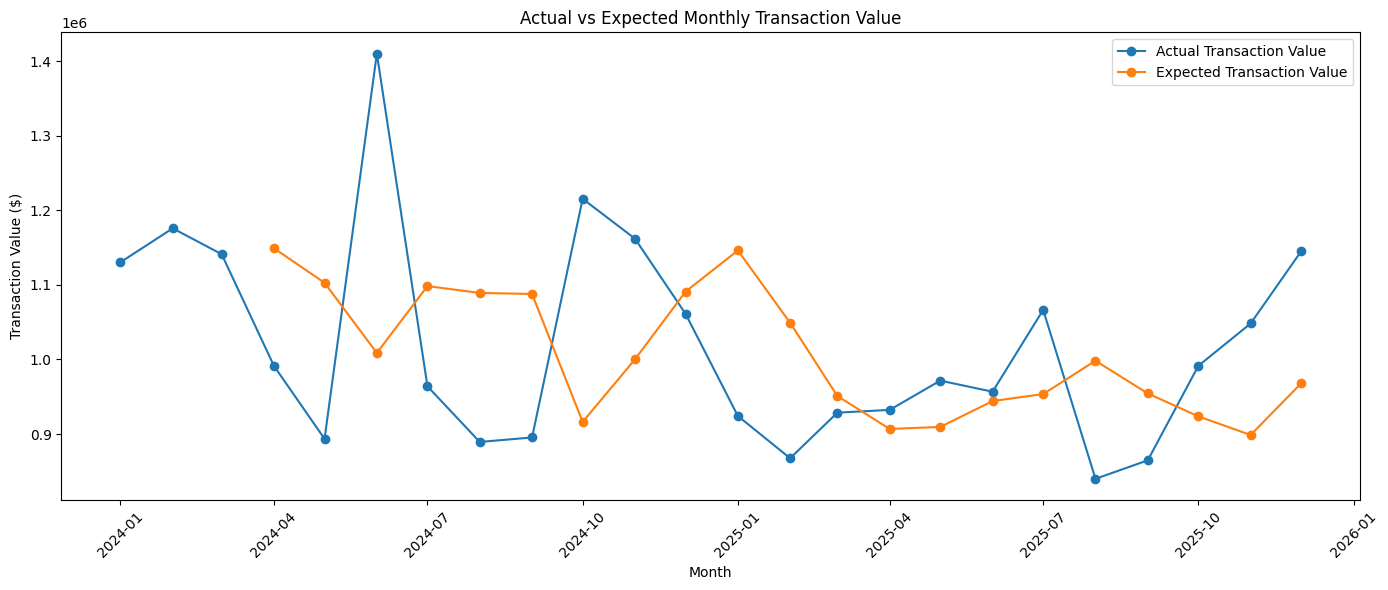

In [17]:
plt.figure(figsize=(14, 6))

plt.plot(
    variance_analysis["month"],
    variance_analysis["actual_transaction_value"],
    marker="o",
    label="Actual Transaction Value"
)

plt.plot(
    variance_analysis["month"],
    variance_analysis["expected_transaction_value"],
    marker="o",
    label="Expected Transaction Value"
)

plt.title("Actual vs Expected Monthly Transaction Value")
plt.xlabel("Month")
plt.ylabel("Transaction Value ($)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()

## Monthly Transaction Value Variance

Analyze the percentage difference between actual transaction value and the historical baseline.

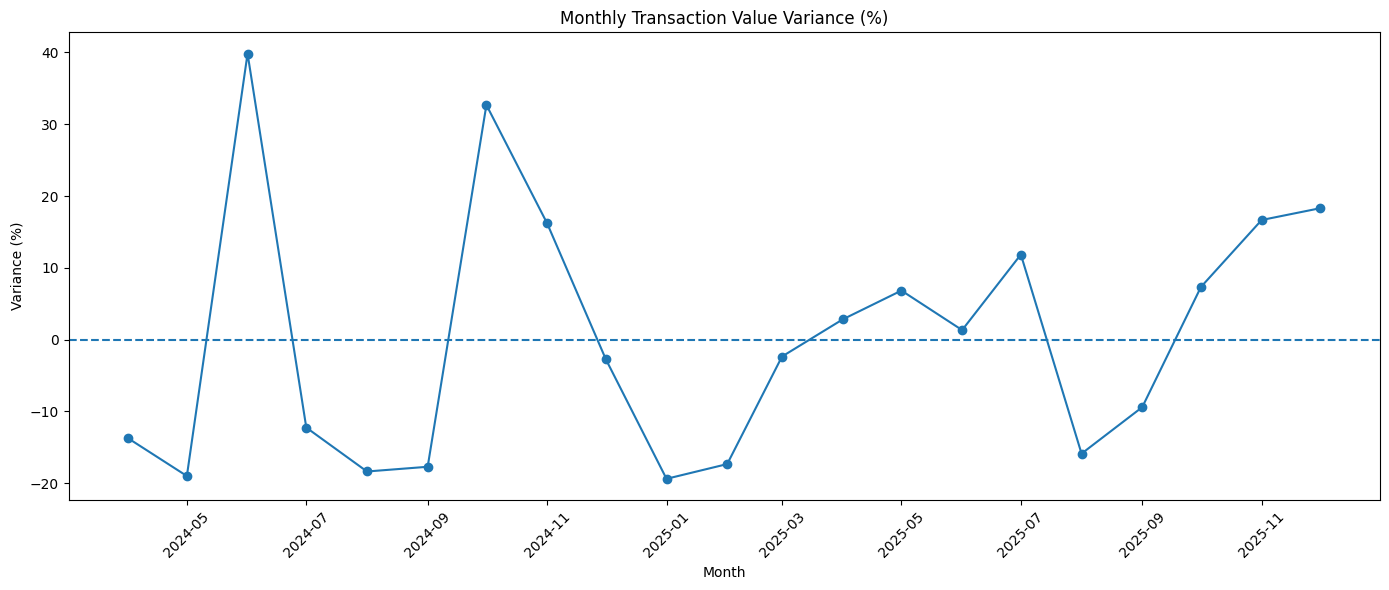

In [18]:
plt.figure(figsize=(14, 6))

plt.plot(
    variance_analysis["month"],
    variance_analysis["transaction_value_variance_percent"],
    marker="o"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Monthly Transaction Value Variance (%)")
plt.xlabel("Month")
plt.ylabel("Variance (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Largest Positive and Negative Variances

Identify the months with the largest deviations from the historical baseline.

In [19]:
variance_ranked = variance_analysis[
    variance_analysis["expected_transaction_value"].notna()
].copy()

variance_ranked["absolute_variance_percent"] = (
    variance_ranked["transaction_value_variance_percent"]
    .abs()
)

largest_variances = (
    variance_ranked
    .sort_values(
        "absolute_variance_percent",
        ascending=False
    )
    .head(10)
)

largest_variances[
    [
        "month",
        "actual_transaction_value",
        "expected_transaction_value",
        "transaction_value_variance",
        "transaction_value_variance_percent",
        "performance_status"
    ]
]

,month,actual_transaction_value,expected_transaction_value,transaction_value_variance,transaction_value_variance_percent,performance_status
5,2024-06-01,1410588.64,1.008752e+06,401836.726667,39.835040,Above Baseline
9,2024-10-01,1215672.46,9.162224e+05,299450.026667,32.683114,Above Baseline
12,2025-01-01,924220.25,1.146402e+06,-222181.943333,-19.380802,Below Baseline
4,2024-05-01,893482.18,1.102942e+06,-209459.976667,-18.991021,Below Baseline
7,2024-08-01,889335.30,1.089351e+06,-200015.740000,-18.361000,Below Baseline
23,2025-12-01,1145437.34,9.681753e+05,177262.010000,18.308875,Above Baseline
8,2024-09-01,895349.70,1.087969e+06,-192619.046667,-17.704465,Below Baseline
13,2025-02-01,867438.80,1.049251e+06,-181812.656667,-17.327844,Below Baseline
22,2025-11-01,1048382.15,8.986647e+05,149717.420000,16.659986,Above Baseline
10,2024-11-01,1162216.67,1.000119e+06,162097.516667,16.207820,Above Baseline


## Variance Summary

In [20]:
variance_summary = pd.DataFrame({
    "Metric": [
        "Average Actual Monthly Transaction Value",
        "Average Transaction Value Variance",
        "Average Variance %",
        "Largest Positive Variance %",
        "Largest Negative Variance %",
        "Months Above Baseline",
        "Months Below Baseline"
    ],
    "Value": [
        variance_analysis["actual_transaction_value"].mean(),
        variance_analysis["transaction_value_variance"].mean(),
        variance_analysis["transaction_value_variance_percent"].mean(),
        variance_analysis["transaction_value_variance_percent"].max(),
        variance_analysis["transaction_value_variance_percent"].min(),
        (variance_analysis["performance_status"] == "Above Baseline").sum(),
        (variance_analysis["performance_status"] == "Below Baseline").sum()
    ]
})

variance_summary

,Metric,Value
0,Average Actual Monthly Transaction Value,1.019532e+06
1,Average Transaction Value Variance,-6.065500e+03
2,Average Variance %,2.745772e-01
3,Largest Positive Variance %,3.983504e+01
4,Largest Negative Variance %,-1.938080e+01
5,Months Above Baseline,1.000000e+01
6,Months Below Baseline,1.100000e+01


In [21]:
summary_display = variance_summary.copy()

summary_display.loc[
    summary_display["Metric"].str.contains("Value|Variance"),
    "Value"
] = summary_display.loc[
    summary_display["Metric"].str.contains("Value|Variance"),
    "Value"
].round(2)

summary_display

,Metric,Value
0,Average Actual Monthly Transaction Value,1019532.21
1,Average Transaction Value Variance,-6065.50
2,Average Variance %,0.27
3,Largest Positive Variance %,39.84
4,Largest Negative Variance %,-19.38
5,Months Above Baseline,10.00
6,Months Below Baseline,11.00


## Analyst Findings

### Positive Variances

- June 2024 recorded the largest positive transaction-value variance at approximately 39.84% above the historical baseline.
- October 2024 recorded the second-largest positive variance at approximately 32.68%.
- December 2025 recorded an 18.31% positive variance.
- November 2025 recorded a 16.66% positive variance.

### Negative Variances

- January 2025 recorded the largest negative variance at approximately -19.38%.
- May 2024 recorded a -18.99% variance.
- August 2024 recorded a -18.36% variance.
- September 2024 recorded a -17.70% variance.
- February 2025 recorded a -17.33% variance.

### Interpretation

Variance analysis highlights periods where actual transaction value deviated materially from the historical three-month baseline.

The analysis identifies performance exceptions but does not attribute these deviations to specific business causes because the synthetic dataset does not contain explanatory business-event fields.

Further investigation could compare transaction volume, average transaction value, customer activity, transaction type, merchant category, and channel to identify potential drivers of significant variances.